# Datathon - Indicadores (1-8 e 10)

- Isabela Marim Mayerhoffer Pereira - RM 362023
- Lucas Constantino Silva - RM 364620
- Pedro Bugui Garcia - RM 360783
- Sophia Yeshua Senra - RM 362887

## Imports e Abertura de Sessão

In [44]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import xgboost as xgb
import shap
from itertools import combinations
from sklearn.tree import DecisionTreeRegressor, export_text
from sklearn.ensemble import RandomForestRegressor
import pyspark
from pyspark.sql.functions import split, col, lit, when
from pyspark.sql.window import Window


In [2]:
spark = SparkSession.builder \
   .appName("MinhaAplicacaoSpark") \
   .master("local[4]") \
   .getOrCreate()

print(f"Versão do Spark: {spark.version}")

Versão do Spark: 4.0.2


## Import dos Dados

In [3]:
spark = SparkSession.builder.appName("Test").getOrCreate()

pdf = pd.read_excel('/content/fat_datathon.xlsx')
df = spark.createDataFrame(pdf)

df.printSchema()
df.show(5,False)

root
 |-- ra: string (nullable = true)
 |-- iaa_autoavaliacao: double (nullable = true)
 |-- ida_desempenho_academico: double (nullable = true)
 |-- ieg_engajamento_atividades: double (nullable = true)
 |-- ipp_psicopedagogicos: double (nullable = true)
 |-- ian_adequacao_nivel: double (nullable = true)
 |-- ips_aspectos_psicossociais: double (nullable = true)
 |-- ipv_ponto_virada: double (nullable = true)
 |-- pedra_2020: string (nullable = true)
 |-- pedra_2021: string (nullable = true)
 |-- pedra_2022: string (nullable = true)
 |-- pedra_2023: string (nullable = true)
 |-- pedra_2024: string (nullable = true)
 |-- inde_indice_desen_educacional: double (nullable = true)
 |-- requer_psicologia: string (nullable = true)
 |-- atingiu_pv: string (nullable = true)
 |-- defasagem: double (nullable = true)
 |-- destaque_ieg: string (nullable = true)
 |-- destaque_ida: string (nullable = true)
 |-- destaque_ipv: string (nullable = true)
 |-- ano_arquivo: long (nullable = true)

+----+------

## KPIs

### 1. Adequação do nível (IAN)

Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao longo do ano?

In [4]:
df_ian = df.select("ra","ian_adequacao_nivel","ano_arquivo")

df_ian = (
    df_ian
    .groupBy("ano_arquivo")
    .agg(
        F.round(F.avg("ian_adequacao_nivel"),2).alias("media_ian"),
        F.expr("percentile_approx(ian_adequacao_nivel, 0.5)").alias("mediana_ian"),
        F.count("*").alias("qtd_registros")
    )
    .orderBy("ano_arquivo")
)

df_ian.show()

+-----------+---------+-----------+-------------+
|ano_arquivo|media_ian|mediana_ian|qtd_registros|
+-----------+---------+-----------+-------------+
|       2022|     6.42|        5.0|          860|
|       2023|     7.24|        5.0|         1014|
|       2024|     7.68|       10.0|         1156|
+-----------+---------+-----------+-------------+



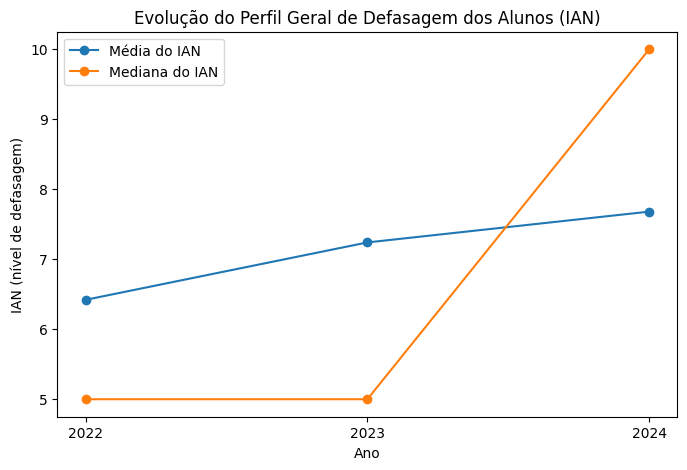

In [5]:
df_pd = df_ian.toPandas()

plt.figure(figsize=(8, 5))

plt.plot(
    df_pd["ano_arquivo"],
    df_pd["media_ian"],
    marker="o",
    label="Média do IAN"
)

plt.plot(
    df_pd["ano_arquivo"],
    df_pd["mediana_ian"],
    marker="o",
    label="Mediana do IAN"
)

plt.xlabel("Ano")
plt.ylabel("IAN (nível de defasagem)")
plt.title("Evolução do Perfil Geral de Defasagem dos Alunos (IAN)")
plt.legend()
plt.xticks(df_pd["ano_arquivo"])

plt.show()


A análise do gráfico demonstra que o nível de adequação dos alunos, medido pelo IAN, apresenta melhora contínua ao longo dos anos. Enquanto em 2022 e 2023 predominava a classificação ‘Moderada’, em 2024 observa-se maior concentração de alunos na classificação ‘Em Fase’, o que indica progresso no processo educacional e diminuição da defasagem geral.

In [6]:
df_ian = df.groupBy("ian_adequacao_nivel", "ano_arquivo").count().orderBy("ian_adequacao_nivel")

df_ian.orderBy("ano_arquivo", "ian_adequacao_nivel").show()

+-------------------+-----------+-----+
|ian_adequacao_nivel|ano_arquivo|count|
+-------------------+-----------+-----+
|                2.5|       2022|   28|
|                5.0|       2022|  573|
|               10.0|       2022|  259|
|                2.5|       2023|   14|
|                5.0|       2023|  538|
|               10.0|       2023|  462|
|                2.5|       2024|    3|
|                5.0|       2024|  531|
|               10.0|       2024|  622|
+-------------------+-----------+-----+



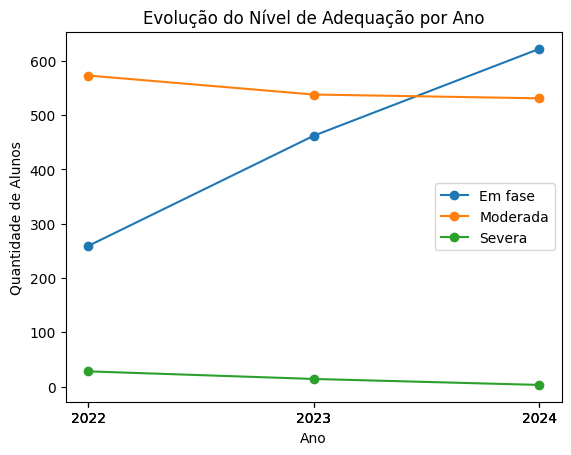

In [7]:
df_plot = df_ian.select("ian_adequacao_nivel", "ano_arquivo", "count")

# Converte para Pandas
pdf = df_plot.toPandas()

# Mapeando os valores numéricos para a classificação textual
map_classificacao = {
    2.5: "Severa",
    5.0: "Moderada",
    10.0: "Em fase"
}

pdf["classificacao"] = pdf["ian_adequacao_nivel"].map(map_classificacao)

# Pivotando para formato ideal de gráfico
pdf_pivot = pdf.pivot(
    index="ano_arquivo",
    columns="classificacao",
    values="count"
).sort_index()

# Criando o gráfico
plt.figure()

for coluna in pdf_pivot.columns:
    plt.plot(pdf_pivot.index, pdf_pivot[coluna], marker='o', label=coluna)

plt.xlabel("Ano")
plt.ylabel("Quantidade de Alunos")
plt.title("Evolução do Nível de Adequação por Ano")
plt.legend()
plt.xticks(pdf["ano_arquivo"])

plt.show()


A análise do gráfico evidencia uma redução consistente no número de alunos em defasagem severa ao longo dos anos, indicando avanço significativo na recuperação dos casos mais críticos. Observa-se também uma diminuição na classificação moderada, sugerindo que parte desses alunos está evoluindo para níveis mais adequados. Como consequência, há um crescimento expressivo na quantidade de alunos “Em fase”, o que sinaliza melhora no desempenho e maior alinhamento à trajetória educacional esperada.

Esse movimento sugere efetividade das ações pedagógicas implementadas no período, com migração gradual dos alunos das faixas de maior defasagem para a fase adequada.

### 2. Desempenho acadêmico (IDA)
O desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo ao longo das fases e anos?

In [8]:
# Converte o Spark DataFrame para Pandas
df_pd = df.toPandas()

# 1 - Criando base com colunas necessárias
df_limpo = df_pd.dropna(subset=['ida_desempenho_academico', 'ips_aspectos_psicossociais'])

# Racional para o IDA por Ano
ida_anual = df_limpo.groupby('ano_arquivo')['ida_desempenho_academico'].mean()

print("Evolução do IDA:\n", ida_anual)

Evolução do IDA:
 ano_arquivo
2022    6.092907
2023    6.669495
2024    6.349934
Name: ida_desempenho_academico, dtype: float64


In [9]:
# Agrupando por ano e calculando a média do IDA
ida_evolucao = df_pd.groupby('ano_arquivo')['ida_desempenho_academico'].mean().reset_index()

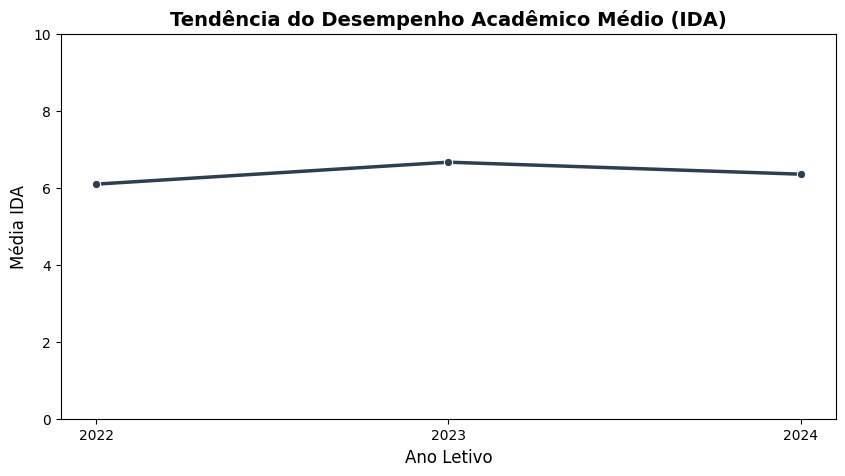

In [10]:
# Editando Grádico
plt.figure(figsize=(10, 5))
sns.lineplot(data=ida_evolucao, x='ano_arquivo', y='ida_desempenho_academico',
             marker='o', linewidth=2.5, color='#2c3e50')


plt.title('Tendência do Desempenho Acadêmico Médio (IDA)', fontsize=14, fontweight='bold')
plt.xlabel('Ano Letivo', fontsize=12)
plt.ylabel('Média IDA', fontsize=12)
plt.xticks(ida_evolucao['ano_arquivo']) # Garante que mostre apenas os anos 2022, 2023, 2024
plt.ylim(0, 10) # Escala de 0 a 10
plt.show()

### 3. Engajamento nas atividades (IEG)
O grau de engajamento dos alunos (IEG) tem relação direta com seus indicadores de desempenho (IDA) e
do ponto de virada (IPV)?

In [11]:
df_IEG = df.toPandas().rename(columns={'iaa_autoavaliacao': 'IAA',
                               'ida_desempenho_academico': 'IDA',
                               'ieg_engajamento_atividades' : 'IEG',
                               'ipp_psicopedagogicos' : 'IPP',
                               'ian_adequacao_nivel' : 'IAN',
                               'ips_aspectos_psicossociais' : 'IPS',
                               'ipv_ponto_virada' : 'IPV' }, inplace=False)

In [12]:
df_IEG.head()

,ra,IAA,IDA,IEG,IPP,IAN,IPS,IPV,pedra_2020,pedra_2021,...,pedra_2023,pedra_2024,inde_indice_desen_educacional,requer_psicologia,atingiu_pv,defasagem,destaque_ieg,destaque_ida,destaque_ipv,ano_arquivo
0,RA-1,8.3,4.0,4.1,NaN,5.0,5.6,7.28,Ametista,Ametista,...,NaN,NaN,5.78,Requer avaliação,Não,-1.0,Melhorar,Melhorar,Melhorar,2022
1,RA-2,8.8,6.8,5.2,NaN,10.0,6.3,6.78,Ametista,Ametista,...,NaN,NaN,7.06,Sem limitações,Não,0.0,Melhorar,Melhorar,Melhorar,2022
2,RA-3,0.0,5.6,7.9,NaN,10.0,5.6,7.56,Ametista,Ametista,...,NaN,NaN,6.59,Sem limitações,Não,0.0,Destaque,Melhorar,Destaque,2022
3,RA-4,8.8,5.0,4.5,NaN,10.0,5.6,5.28,Ametista,Ametista,...,NaN,NaN,5.95,Requer avaliação,Não,0.0,Melhorar,Melhorar,Melhorar,2022
4,RA-5,7.9,5.2,8.6,NaN,10.0,5.6,7.39,Ametista,Ametista,...,NaN,NaN,7.43,Requer avaliação,Não,0.0,Destaque,Melhorar,Melhorar,2022


In [13]:
# analise correlação 2022
df_2022 = df_IEG[df_IEG['ano_arquivo'] == 2022]

In [14]:
campos_2022 = df_2022[['IAN', 'IDA', 'IEG', 'IAA', 'IPS',  'IPV']]

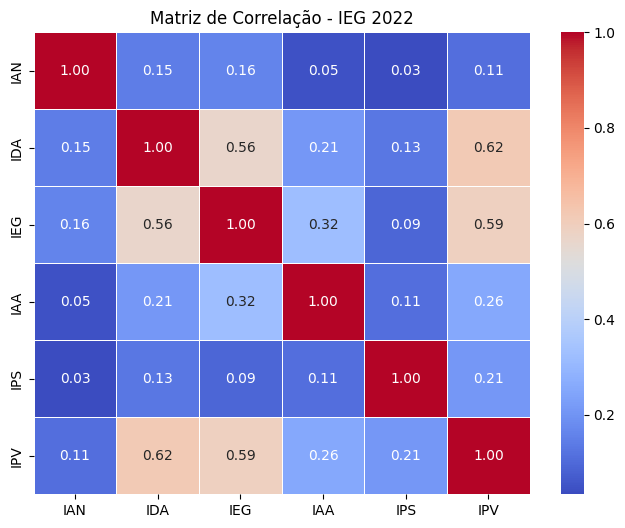

In [15]:
matriz_corr_2022 = campos_2022.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(matriz_corr_2022, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Matriz de Correlação - IEG 2022')
plt.show()

In [16]:
# analise correlação 2023
df_2023 = df_IEG[df_IEG['ano_arquivo'] == 2023]

In [17]:
campos_2023 = df_2023[['IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP' , 'IPV']]

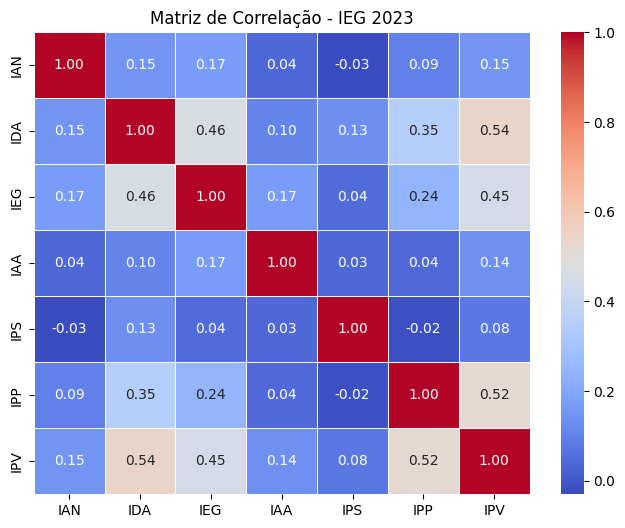

In [18]:
matriz_corr_2023 = campos_2023.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(matriz_corr_2023, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Matriz de Correlação - IEG 2023')
plt.show()

In [19]:
# analise correlação 2024
df_2024 = df_IEG[df_IEG['ano_arquivo'] == 2024]

In [20]:
campos_2024 = df_2024[['IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP' , 'IPV']]

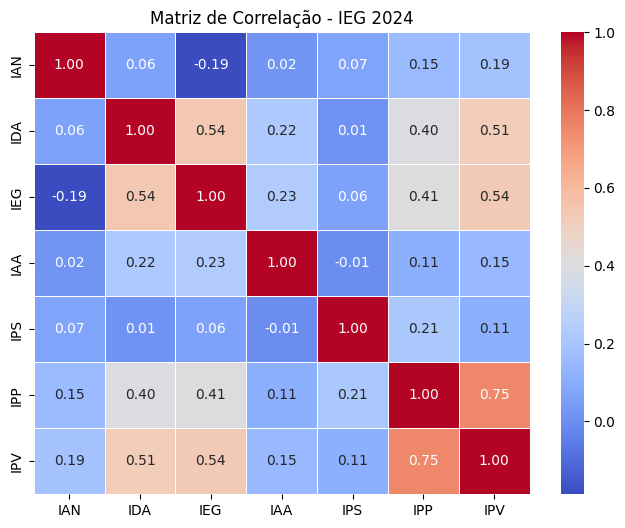

In [21]:
matriz_corr_2024 = campos_2024.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(matriz_corr_2024, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Matriz de Correlação - IEG 2024')
plt.show()

A análise das matrizes de correlação de 2022, 2023 e 2024 evidencia uma relação positiva e consistente entre o grau de engajamento dos alunos (IEG), o desempenho acadêmico (IDA) e o ponto de virada (IPV).

A manutenção desse padrão ao longo de três anos consecutivos indica que o engajamento está estruturalmente associado tanto ao desempenho quanto à ocorrência de pontos de virada, sugerindo que alunos mais engajados tendem a apresentar melhores resultados e maior evolução acadêmica ou comportamental.

Embora os coeficientes representem correlação moderada, esses valores são relevantes no contexto educacional, em que múltiplos fatores influenciam os resultados, reforçando a consistência e a importância da relação identificada.

### 4. Autoavaliação (IAA):
As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu desempenho real (IDA) e engajamento (IEG)?

In [45]:
df_questao_4_6 = pd.read_excel("/content/fat_datathon.xlsx", sheet_name="Sheet1")

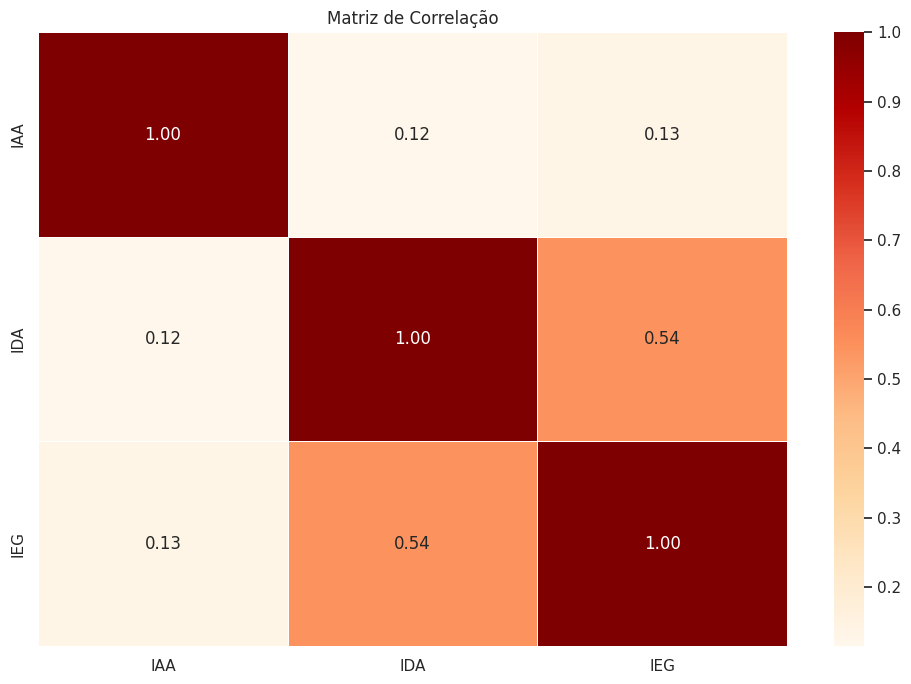

In [48]:
cols = [
    "iaa_autoavaliacao",
    "ida_desempenho_academico",
    "ieg_engajamento_atividades"
]

df_corr = df_questao_4_6[cols].dropna()

corr_matrix = df_corr.corr()

corr_matrix.columns = ["IAA", "IDA", "IEG"]
corr_matrix.index = ["IAA", "IDA", "IEG"]

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="OrRd",
    linewidths=0.5
)

plt.title("Matriz de Correlação")
plt.tight_layout()

plt.show()

### 5. Aspectos psicossociais (IPS)
Há padrões psicossociais (IPS) que antecedem quedas de desempenho acadêmico ou de engajamento?

In [24]:
# 2.  Preparação da base (Ordenação e Shift)
df_sorted = df_pd.sort_values(['ra', 'ano_arquivo'])
df_sorted['ida_proximo_ano'] = df_sorted.groupby('ra')['ida_desempenho_academico'].shift(-1)

# Identificando queda (ex: caiu mais de 0.5 pontos)
df_sorted['houve_queda'] = (df_sorted['ida_desempenho_academico'] - df_sorted['ida_proximo_ano']) > 0.5

# Média de IPS para quem vai cair vs quem vai ficar estável/subir
analise_ips = df_sorted.groupby('houve_queda')['ips_aspectos_psicossociais'].mean()
print("\nIPS Médio (Antecedente):\n", analise_ips)


IPS Médio (Antecedente):
 houve_queda
False    6.391555
True     5.803360
Name: ips_aspectos_psicossociais, dtype: float64


In [25]:
# 3. Preparação da base (Ordenação e Shift)
df_sorted = df_pd.sort_values(['ra', 'ano_arquivo'])
df_sorted['ida_proximo_ano'] = df_sorted.groupby('ra')['ida_desempenho_academico'].shift(-1)

#  Identificando queda (ex: caiu mais de 0.5 pontos)
df_sorted['houve_queda'] = (df_sorted['ida_desempenho_academico'] - df_sorted['ida_proximo_ano']) > 0.5

# Agrupamento por Ano e por Status de Queda
# Filtra apenas 2022 e 2023, pois 2024 não tem um "próximo ano" para comparar
analise_por_ano = df_sorted[df_sorted['ano_arquivo'].isin([2022, 2023])].groupby(
    ['ano_arquivo', 'houve_queda']
)['ips_aspectos_psicossociais'].mean().unstack()

# Renomeando as colunas
analise_por_ano.columns = ['Média IPS (Estável/Melhorou)', 'Média IPS (Terá Queda)']
analise_por_ano.index.name = 'Ano da Avaliação IPS'

print("Análise Preditiva: O IPS de hoje prevendo a queda")
print(analise_por_ano)

Análise Preditiva: O IPS de hoje prevendo a queda
                      Média IPS (Estável/Melhorou)  Média IPS (Terá Queda)
Ano da Avaliação IPS                                                      
2022                                      6.924658                6.841379
2023                                      5.125280                5.107921


/tmp/ipykernel_1054/275339973.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_analise, x='status_queda', y='ips_aspectos_psicossociais', palette='Set2')


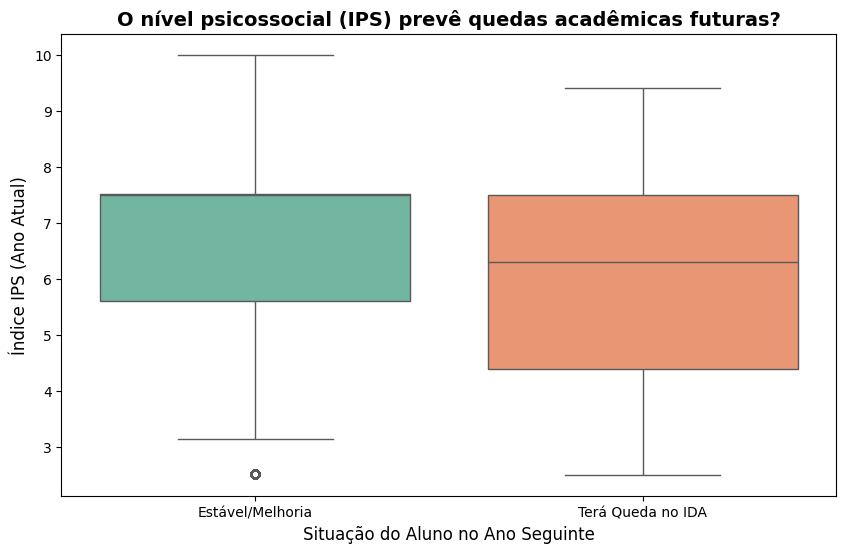

In [26]:
# Racional: Ordenar por aluno e ano para ver o futuro - Comando SHIFT -1
# Groupby('ra') Garante que só vamos comprar o proprio aluno.
df_sorted = df_pd.sort_values(['ra', 'ano_arquivo'])
df_sorted['ida_prox_ano'] = df_sorted.groupby('ra')['ida_desempenho_academico'].shift(-1)

# Defini "Queda" como uma redução maior que 0.5 pontos na nota do ano seguinte
df_sorted['houve_queda'] = (df_sorted['ida_desempenho_academico'] - df_sorted['ida_prox_ano']) > 0.5
df_sorted['status_queda'] = df_sorted['houve_queda'].map({True: 'Terá Queda no IDA', False: 'Estável/Melhoria'})

# Limpeza de nulos (último ano não tem "próximo ano" para comparar)
df_analise = df_sorted.dropna(subset=['status_queda', 'ips_aspectos_psicossociais'])

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_analise, x='status_queda', y='ips_aspectos_psicossociais', palette='Set2')

plt.title('O nível psicossocial (IPS) prevê quedas acadêmicas futuras?', fontsize=14, fontweight='bold')
plt.xlabel('Situação do Aluno no Ano Seguinte', fontsize=12)
plt.ylabel('Índice IPS (Ano Atual)', fontsize=12)
plt.show()

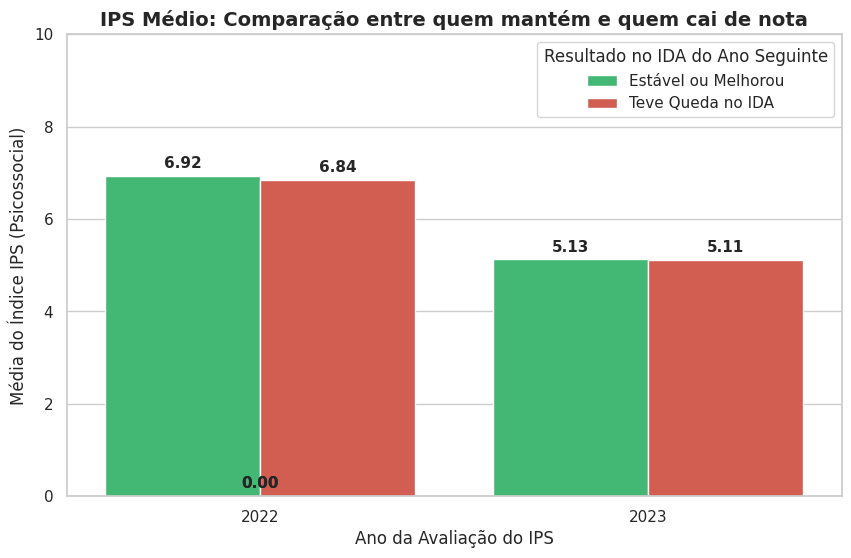

In [27]:
# Preparação da base (Ordenação e Shift)
df_sorted['ida_prox_ano'] = df_sorted.groupby('ra')['ida_desempenho_academico'].shift(-1)

# Definindo quem teve queda (perda > 0.5 na nota)
df_sorted['houve_queda'] = (df_sorted['ida_desempenho_academico'] - df_sorted['ida_prox_ano']) > 0.5

# Filtrando apenas os anos onde existe um "ano seguinte" para comparar (2022 e 2023)
df_plot = df_sorted[df_sorted['ano_arquivo'].isin([2022, 2023])].copy()
df_plot['Status no Ano Seguinte'] = df_plot['houve_queda'].map({True: 'Teve Queda no IDA', False: 'Estável ou Melhorou'})

# 2. Criação do Gráfico de Barras
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=df_plot,
    x='ano_arquivo',
    y='ips_aspectos_psicossociais',
    hue='Status no Ano Seguinte',
    palette=['#2ecc71', '#e74c3c'], # Verde para positivo, Vermelho para negativo
    errorbar=None # Foca na média simples
)

# Adicionando os números em cima das barras
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', xytext = (0, 9),
                textcoords = 'offset points', fontsize=11, fontweight='bold')

plt.title('IPS Médio: Comparação entre quem mantém e quem cai de nota', fontsize=14, fontweight='bold')
plt.ylabel('Média do Índice IPS (Psicossocial)')
plt.xlabel('Ano da Avaliação do IPS')
plt.ylim(0, 10)
plt.legend(title='Resultado no IDA do Ano Seguinte')
plt.show()

### 6. Aspectos psicopedagógicos (IPP)
As avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem identificada pelo IAN?

<Figure size 640x480 with 0 Axes>

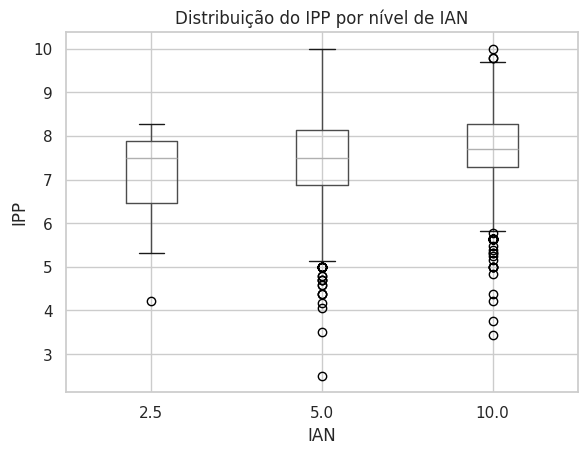

In [50]:
plt.figure()

df_questao_4_6.boxplot(column="ipp_psicopedagogicos",
                by="ian_adequacao_nivel")

plt.xlabel("IAN")
plt.ylabel("IPP")
plt.title("Distribuição do IPP por nível de IAN")
plt.suptitle("")

plt.show()

### 7. Ponto de virada (IPV)
Quais comportamentos - acadêmicos, emocionais ou de engajamento - mais influenciam o IPV ao longo do tempo?

In [29]:
df_IPV = df_IEG.copy()

In [30]:
df_IPV.head()

,ra,IAA,IDA,IEG,IPP,IAN,IPS,IPV,pedra_2020,pedra_2021,...,pedra_2023,pedra_2024,inde_indice_desen_educacional,requer_psicologia,atingiu_pv,defasagem,destaque_ieg,destaque_ida,destaque_ipv,ano_arquivo
0,RA-1,8.3,4.0,4.1,NaN,5.0,5.6,7.28,Ametista,Ametista,...,NaN,NaN,5.78,Requer avaliação,Não,-1.0,Melhorar,Melhorar,Melhorar,2022
1,RA-2,8.8,6.8,5.2,NaN,10.0,6.3,6.78,Ametista,Ametista,...,NaN,NaN,7.06,Sem limitações,Não,0.0,Melhorar,Melhorar,Melhorar,2022
2,RA-3,0.0,5.6,7.9,NaN,10.0,5.6,7.56,Ametista,Ametista,...,NaN,NaN,6.59,Sem limitações,Não,0.0,Destaque,Melhorar,Destaque,2022
3,RA-4,8.8,5.0,4.5,NaN,10.0,5.6,5.28,Ametista,Ametista,...,NaN,NaN,5.95,Requer avaliação,Não,0.0,Melhorar,Melhorar,Melhorar,2022
4,RA-5,7.9,5.2,8.6,NaN,10.0,5.6,7.39,Ametista,Ametista,...,NaN,NaN,7.43,Requer avaliação,Não,0.0,Destaque,Melhorar,Melhorar,2022


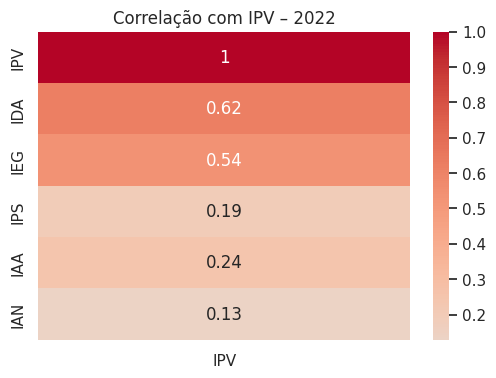

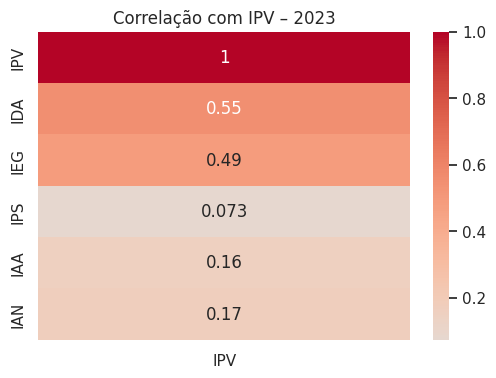

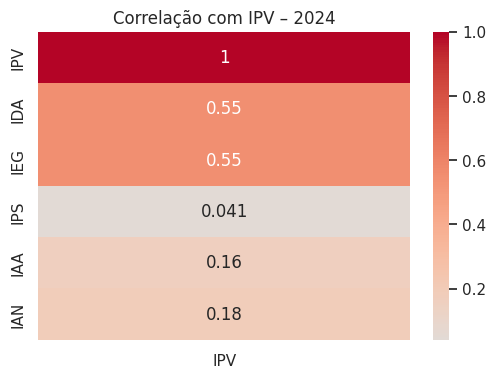

In [31]:
vars_corr = ["IPV", "IDA", "IEG", "IPS", "IAA", "IAN"]

for year in sorted(df_IPV["ano_arquivo"].unique()):
    corr = (
        df_IPV[df_IPV["ano_arquivo"] == year][vars_corr]
        .corr(method="spearman")
    )

    plt.figure(figsize=(6,4))
    sns.heatmap(
        corr[["IPV"]],
        annot=True,
        cmap="coolwarm",
        center=0
    )
    plt.title(f"Correlação com IPV – {year}")
    plt.show()

A análise comparativa entre 2022 e 2024 mostra uma consolidação dos fatores que impulsionam o Ponto de Virada (IPV), destacando que o sucesso do aluno está cada vez mais associado a critérios objetivos de desempenho. O Desempenho Acadêmico (IDA) e o Engajamento nas Atividades (IEG) confirmam-se como os principais pilares do IPV.

Observa-se também a perda de relevância dos Aspectos Psicossociais (IPS), cuja relação com o IPV se tornou praticamente nula em 2024. Já variáveis como Autoavaliação (IAA) e Adequação de Nível (IAN) mantiveram correlações baixas e estáveis.

Em síntese, o aluno que atinge o Ponto de Virada é aquele focado em desempenho e participação ativa, indicando que estratégias pedagógicas devem priorizar proficiência acadêmica e estímulos ao engajamento contínuo.

### 8. Multidimensionalidade dos indicadores
Quais combinações de indicadores (IDA + IEG + IPS + IPP) melhor explicam o desempenho global do
aluno (INDE)?

In [32]:
# 2. SELEÇÃO DE VARIÁVEIS (Questão 8)
features = ['ida_desempenho_academico', 'ieg_engajamento_atividades',
            'ips_aspectos_psicossociais', 'ipp_psicopedagogicos']
target = 'inde_indice_desen_educacional'

In [33]:
# Limpeza: Para ML, precisamos remover linhas onde o INDE ou os indicadores são nulos
df_ml = df.select(features + [target]).dropna()

X_pd = df_ml.select(features).toPandas()
y_pd = df_ml.select(target).toPandas()

In [34]:
# 3. TREINAMENTO DO MODELO (XGBoost)
model = xgb.XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)
model.fit(X_pd, y_pd.values.ravel())

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [35]:
# O SHAP calcula a contribuição de cada variável para cada aluno individualmente
explainer = shap.Explainer(model, X_pd)
shap_values = explainer(X_pd)

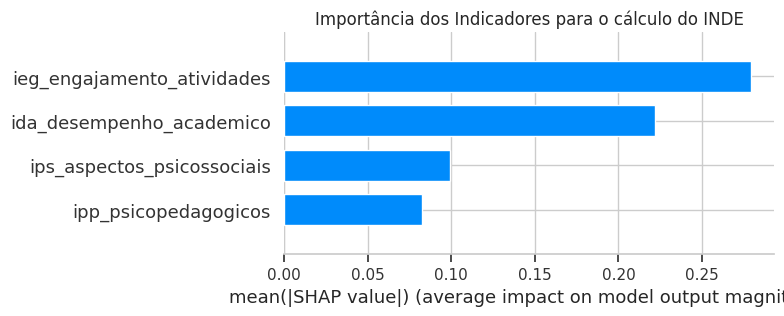

In [36]:
# Gráfico 1: Importância Global (Quais indicadores mais pesam no INDE?)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_pd, plot_type="bar", show=False)
plt.title("Importância dos Indicadores para o cálculo do INDE")
plt.show()

<Figure size 1000x600 with 0 Axes>

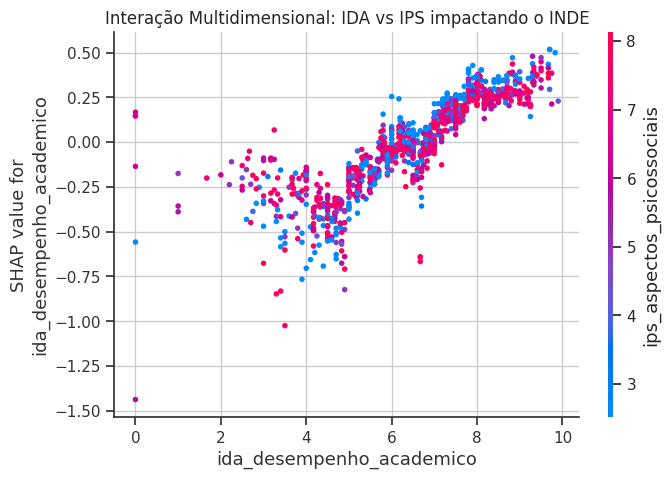

In [37]:
# Gráfico 2: Combinação/Interação (IDA + IPS)
plt.figure(figsize=(10, 6))
shap.dependence_plot("ida_desempenho_academico", shap_values.values, X_pd,
                     interaction_index="ips_aspectos_psicossociais", show=False)
plt.title("Interação Multidimensional: IDA vs IPS impactando o INDE")
plt.show()

In [38]:
# 2. MODELO 1: Random Forest (Para ver a Importância Real)
# Ele testa milhares de combinações para ver quem manda mais no INDE
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_pd, y_pd)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor(random_state=42)

In [39]:
# 3. MODELO 2: Decision Tree (Para ver as Regras de Combinação)
# Ele cria o "Mapa" que diz: Se X > valor E Y > valor, então Nota = Z
tree = DecisionTreeRegressor(max_depth=3, random_state=42)
tree.fit(X_pd, y_pd)

DecisionTreeRegressor(max_depth=3, random_state=42)

In [40]:
# --- RESULTADOS PARA O TRABALHO ---
print("1. IMPORTÂNCIA DAS VARIÁVEIS (RANKING ML):")
importancia = pd.Series(rf.feature_importances_, index=X_pd.columns)
print(importancia.sort_values(ascending=False))

1. IMPORTÂNCIA DAS VARIÁVEIS (RANKING ML):
ieg_engajamento_atividades    0.424269
ida_desempenho_academico      0.293890
ipp_psicopedagogicos          0.165522
ips_aspectos_psicossociais    0.116320
dtype: float64


In [41]:
print("\n2. REGRAS DE COMBINAÇÃO (ÁRVORE DE DECISÃO):")
regras = export_text(tree, feature_names=list(X_pd.columns))
print(regras)


2. REGRAS DE COMBINAÇÃO (ÁRVORE DE DECISÃO):
|--- ieg_engajamento_atividades <= 8.76
|   |--- ida_desempenho_academico <= 7.18
|   |   |--- ieg_engajamento_atividades <= 7.49
|   |   |   |--- value: [6.61]
|   |   |--- ieg_engajamento_atividades >  7.49
|   |   |   |--- value: [6.96]
|   |--- ida_desempenho_academico >  7.18
|   |   |--- ida_desempenho_academico <= 7.68
|   |   |   |--- value: [7.19]
|   |   |--- ida_desempenho_academico >  7.68
|   |   |   |--- value: [7.52]
|--- ieg_engajamento_atividades >  8.76
|   |--- ida_desempenho_academico <= 6.13
|   |   |--- ips_aspectos_psicossociais <= 6.88
|   |   |   |--- value: [7.10]
|   |   |--- ips_aspectos_psicossociais >  6.88
|   |   |   |--- value: [7.56]
|   |--- ida_desempenho_academico >  6.13
|   |   |--- ieg_engajamento_atividades <= 9.51
|   |   |   |--- value: [7.72]
|   |   |--- ieg_engajamento_atividades >  9.51
|   |   |   |--- value: [8.01]



### 10. Efetividade do programa

Os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases (Quartzo, Ágata, Ametista e Topázio), confirmando o impacto real do programa?

In [42]:
df_pedras = df.select("ra", "pedra_2020", "pedra_2021", "pedra_2022", "pedra_2023", "pedra_2024", "ano_arquivo")

df_pedras = (
    df_pedras
    .groupBy("ra")
    .agg(
        F.first("pedra_2020", ignorenulls=True).alias("pedra_2020"),
        F.first("pedra_2021", ignorenulls=True).alias("pedra_2021"),
        F.first("pedra_2022", ignorenulls=True).alias("pedra_2022"),
        F.first("pedra_2023", ignorenulls=True).alias("pedra_2023"),
        F.first("pedra_2024", ignorenulls=True).alias("pedra_2024")
    )
)

df_pedras = (
    df_pedras
    .selectExpr(
        "ra",
        "stack(5, \
            '2020', pedra_2020, \
            '2021', pedra_2021, \
            '2022', pedra_2022, \
            '2023', pedra_2023, \
            '2024', pedra_2024 \
        ) as (ano, pedra)"
    )
    .filter(F.col("pedra").isNotNull())
)

mapa_pedra = F.create_map(
    F.lit("Quartzo"), F.lit(1),
    F.lit("Ágata"), F.lit(2),
    F.lit("Ametista"), F.lit(3),
    F.lit("Topázio"), F.lit(4)
)

df_pedras = df_pedras.withColumn(
    "nivel_pedra",
    mapa_pedra[F.col("pedra")]
)

df_pedras = (
    df_pedras
    .groupBy("ano")
    .agg(
        F.round(F.avg("nivel_pedra"),2).alias("nivel_medio"),
        F.countDistinct("ra").alias("qtd_alunos")
    )
    .orderBy("ano")
)

df_pedras.show()

+----+-----------+----------+
| ano|nivel_medio|qtd_alunos|
+----+-----------+----------+
|2020|       2.87|      1661|
|2021|       2.69|      1661|
|2022|       2.55|      1661|
|2023|       3.24|      1661|
|2024|       3.11|      1661|
+----+-----------+----------+



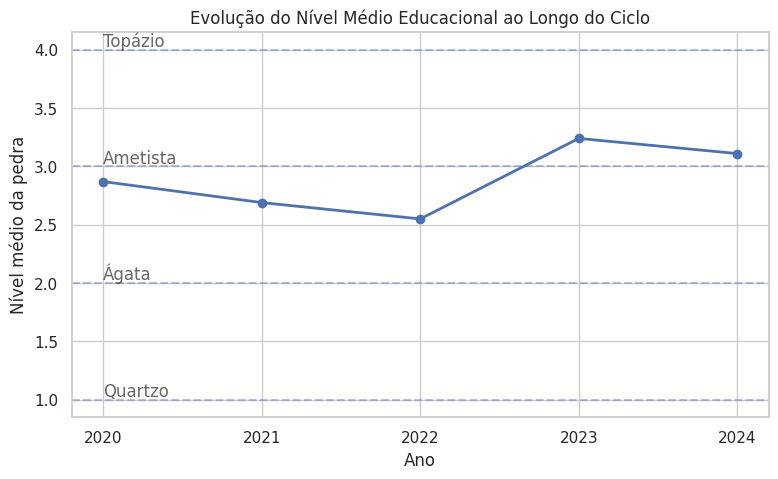

In [43]:
df_pd = df_pedras.toPandas()

plt.figure(figsize=(9, 5))

plt.plot(
    df_pd["ano"],
    df_pd["nivel_medio"],
    marker="o",
    linewidth=2
)

# Linhas de referência das pedras
plt.axhline(1, linestyle="--", alpha=0.4)
plt.axhline(2, linestyle="--", alpha=0.4)
plt.axhline(3, linestyle="--", alpha=0.4)
plt.axhline(4, linestyle="--", alpha=0.4)

x_pos = df_pd["ano"].min()  # garante que o texto fique dentro do gráfico

plt.text(x_pos, 1.03, "Quartzo", alpha=0.7)
plt.text(x_pos, 2.03, "Ágata", alpha=0.7)
plt.text(x_pos, 3.03, "Ametista", alpha=0.7)
plt.text(x_pos, 4.03, "Topázio", alpha=0.7)

plt.xticks(df_pd["ano"])
plt.xlabel("Ano")
plt.ylabel("Nível médio da pedra")
plt.title("Evolução do Nível Médio Educacional ao Longo do Ciclo")

plt.show()

A análise do gráfico evidencia, na média, uma tendência de evolução dos alunos ao longo do ciclo, com progressão entre as diferentes fases educacionais (Quartzo, Ágata, Ametista e Topázio). Embora se observe uma redução do nível médio entre 2020 e 2022, ainda situada dentro da faixa correspondente à pedra Ágata, a partir de 2023 ocorre uma mudança relevante de patamar, com a média dos alunos passando a se concentrar na fase Ametista.